# Transfer Learning on MRI Slices — AlexNet & VGG16

So far in this repo transfer learning was only tried on **CIFAR-10**. Here I apply it to
the **ADNI Alzheimer's MRI** data instead.

The 3D-CNN experiments treated each scan as a full 3D volume. ImageNet-pretrained CNNs are 2D,
so here I take **2D axial slices** out of each `.nii` volume, turn them into 3-channel 224x224
images, and classify them into **AD / CN / MCI**.

**Two models:**
- **VGG16** — true transfer learning: frozen ImageNet base + a new classification head.
- **AlexNet** — Keras/TF has *no* pretrained AlexNet weights, so this one is built from scratch
  and trained on the slices. It is kept here as the architectural comparison (same as the CIFAR notebook).

Dataset / directory layout is the same as the 3D-CNN notebook:
```
train/train/{AD, CN, MCI}
val/val/{AD, CN, MCI}
test/test/{AD, CN, MCI}
```

## 1. Setup & data download (Colab)

In [1]:
from google.colab import userdata
import os

# Store your Kaggle token in Colab Secrets (key icon, left sidebar):
#   Name: KAGGLE_API_TOKEN   Value: <your token>   Notebook access: ON
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -q kaggle

# Download dataset
!kaggle datasets download -d velavansekar/adni-mri-alzheimer-dataset-train-val-test-split

# Unzip
!unzip -q adni-mri-alzheimer-dataset-train-val-test-split.zip

Dataset URL: https://www.kaggle.com/datasets/velavansekar/adni-mri-alzheimer-dataset-train-val-test-split
License(s): unknown
100% 13.6G/13.6G [02:38<00:00, 92.2MB/s]



In [2]:
!pip install nibabel scikit-learn seaborn

import os
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [3]:
base_path = "/content"

train_path = os.path.join(base_path, "train", "train")
val_path   = os.path.join(base_path, "val", "val")
test_path  = os.path.join(base_path, "test", "test")

classes = sorted(os.listdir(train_path))   # ['AD', 'CN', 'MCI']
label_map = {cls: i for i, cls in enumerate(classes)}
num_classes = len(classes)

print("Classes:", label_map)

Classes: {'AD': 0, 'CN': 1, 'MCI': 2}


## 2. From volumes to 2D slices

Each `.nii` is a 3D volume. I pull a handful of **central axial slices** from every volume
(the middle of the brain carries the most signal; the top/bottom slices are mostly empty).
Taking a few slices per scan also gives more 2D training samples from the same number of scans.

Each slice is then:
1. min-max scaled to **0-255** (so ImageNet `preprocess_input` behaves as expected),
2. stacked into **3 channels** (pretrained nets expect RGB),
3. resized to **224x224**.

In [4]:
IMG_SIZE = 224          # input size for both models
SLICES_PER_VOLUME = 5   # central axial slices taken from each scan
MAX_SCANS_PER_CLASS = 60  # cap per class to keep memory/time reasonable; raise if you have RAM

def volume_to_slices(file_path, n_slices=SLICES_PER_VOLUME):
    """Load a NIfTI volume and return a list of (IMG_SIZE, IMG_SIZE, 3) float slices in [0,255]."""
    data = nib.load(file_path).get_fdata()  # (D, H, W)

    depth = data.shape[0]
    center = depth // 2
    half = n_slices // 2
    idxs = range(center - half, center - half + n_slices)

    slices = []
    for z in idxs:
        z = int(np.clip(z, 0, depth - 1))
        sl = data[z]

        # min-max scale this slice to 0-255
        lo, hi = sl.min(), sl.max()
        sl = (sl - lo) / (hi - lo + 1e-8) * 255.0

        # to 3 channels + resize to IMG_SIZE
        sl = np.stack([sl, sl, sl], axis=-1).astype(np.float32)
        sl = tf.image.resize(sl, (IMG_SIZE, IMG_SIZE)).numpy()
        slices.append(sl)
    return slices

In [5]:
def build_dataset(split_path, max_per_class=MAX_SCANS_PER_CLASS):
    X, y = [], []
    for cls in classes:
        class_dir = os.path.join(split_path, cls)
        files = sorted(os.listdir(class_dir))[:max_per_class]
        for f in files:
            for sl in volume_to_slices(os.path.join(class_dir, f)):
                X.append(sl)
                y.append(label_map[cls])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

X_train, y_train = build_dataset(train_path)
X_val,   y_val   = build_dataset(val_path)
X_test,  y_test  = build_dataset(test_path)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (900, 224, 224, 3) (900,)
Val:   (890, 224, 224, 3) (890,)
Test:  (895, 224, 224, 3) (895,)


In [6]:
# one-hot labels (matches the CIFAR notebook's *_cat convention)
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

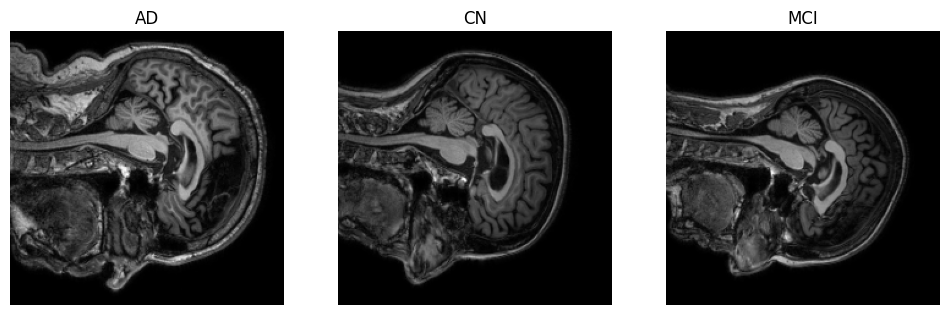

In [7]:
# quick sanity check: show one slice per class
fig, ax = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))
for cls, i in label_map.items():
    idx = np.where(y_train == i)[0][0]
    ax[i].imshow(X_train[idx][..., 0], cmap='gray')
    ax[i].set_title(cls)
    ax[i].axis('off')
plt.show()

## 3. Shared evaluation helpers

Same `plot_history` / `evaluate_predictions` used in the CIFAR notebook so results are comparable.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_predictions(model, x_test, y_test, model_name):
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.show()

    print(f"{model_name} - Classification Report")
    print(classification_report(y_true, y_pred, target_names=classes))

    roc_auc = roc_auc_score(y_test, y_pred_probs, average='macro', multi_class='ovr')
    print(f"ROC AUC Score (OvA): {roc_auc:.4f}")

## 4. VGG16 — transfer learning (frozen ImageNet base)

Same pattern as the CIFAR transfer-learning cell: load VGG16 with ImageNet weights, drop its
top, freeze it, and add a fresh head for the 3 MRI classes. VGG16's own `preprocess_input`
is applied to the 0-255 slices.

In [9]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
BATCH_SIZE = 32

# ImageNet preprocessing for the pretrained base
X_train_vgg = vgg16_preprocess(X_train.copy())
X_val_vgg   = vgg16_preprocess(X_val.copy())
X_test_vgg  = vgg16_preprocess(X_test.copy())

In [10]:
def build_vgg16_transfer():
    base = VGG16(include_top=False, weights='imagenet', input_shape=IMG_SHAPE)
    base.trainable = False   # freeze the pretrained convolutional base

    x = layers.GlobalAveragePooling2D(name='gap')(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return models.Model(inputs=base.input, outputs=outputs, name='VGG16_transfer')

vgg16_tl = build_vgg16_transfer()
vgg16_tl.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
vgg16_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_vgg16 = vgg16_tl.fit(
    X_train_vgg, y_train_cat,
    epochs=10,
    validation_data=(X_val_vgg, y_val_cat),
    batch_size=BATCH_SIZE,
)

vgg16_tl.evaluate(X_test_vgg, y_test_cat)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 897ms/step - accuracy: 0.4311 - loss: 2.5952 - val_accuracy: 0.4337 - val_loss: 1.4757
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 314ms/step - accuracy: 0.6778 - loss: 0.8198 - val_accuracy: 0.4573 - val_loss: 1.2924
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step - accuracy: 0.7778 - loss: 0.5438 - val_accuracy: 0.4652 - val_loss: 1.1784
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.8656 - loss: 0.3625 - val_accuracy: 0.4775 - val_loss: 1.3291
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 321ms/step - accuracy: 0.8767 - loss: 0.3198 - val_accuracy: 0.4978 - val_loss: 1.1833
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 322ms/step - accuracy: 0.9022 - loss: 0.2721 - val_accuracy: 0.4978 - val_loss: 1.3228
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 323ms/step - accuracy: 0.9300 - loss: 0.2113 - val_accuracy: 0.4989 - val_loss: 1.4246
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step - accuracy: 0.9578 - loss: 0.1663 - val_accuracy: 0

[2.0491349697113037, 0.3988826870918274]

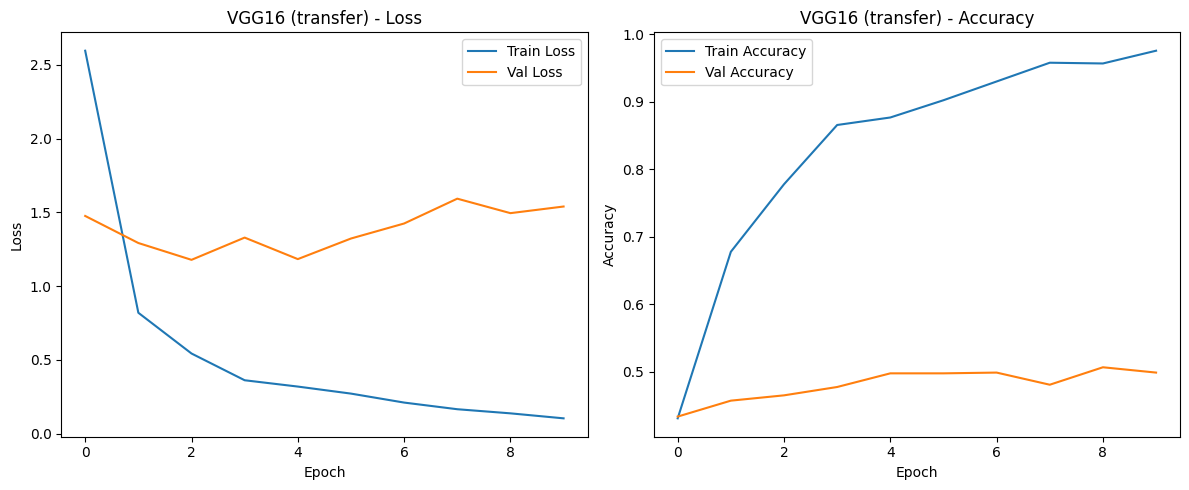

28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step


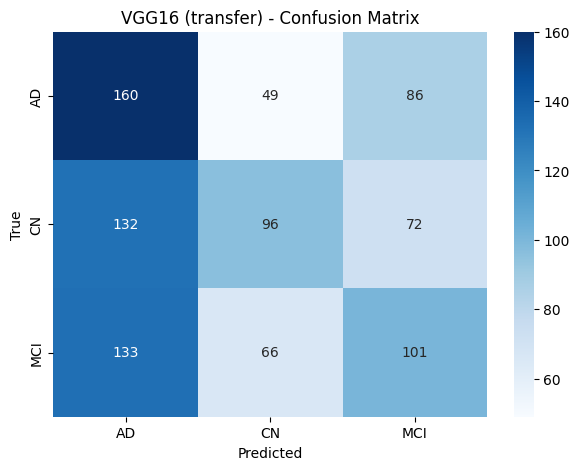

VGG16 (transfer) - Classification Report
              precision    recall  f1-score   support

          AD       0.38      0.54      0.44       295
          CN       0.45      0.32      0.38       300
         MCI       0.39      0.34      0.36       300

    accuracy                           0.40       895
   macro avg       0.41      0.40      0.39       895
weighted avg       0.41      0.40      0.39       895

ROC AUC Score (OvA): 0.5681


In [12]:
plot_history(history_vgg16, "VGG16 (transfer)")
evaluate_predictions(vgg16_tl, X_test_vgg, y_test_cat, "VGG16 (transfer)")

## 5. AlexNet — built from scratch

There is **no pretrained AlexNet** in `keras.applications`, so unlike VGG16 this one can't do
ImageNet transfer learning. I implement the classic AlexNet architecture and train it directly
on the MRI slices, so it serves as the from-scratch baseline against pretrained VGG16
(mirroring how AlexNet was treated in the CIFAR notebook).

Inputs here are simply scaled to [0, 1] rather than ImageNet-normalized.

In [14]:
X_train_an = X_train / 255.0
X_val_an   = X_val   / 255.0
X_test_an  = X_test  / 255.0

In [15]:
def build_alexnet():
    return models.Sequential([
        layers.Input(shape=IMG_SHAPE),
        layers.Conv2D(96, 11, strides=4, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(3, strides=2),

        layers.Conv2D(256, 5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(3, strides=2),

        layers.Conv2D(384, 3, padding='same', activation='relu'),
        layers.Conv2D(384, 3, padding='same', activation='relu'),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(3, strides=2),

        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='AlexNet')

alexnet = build_alexnet()
alexnet.summary()

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │        12,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,760,707 (178.38 MB)

 Trainable params: 46,760,003 (178.38 MB)

 Non-trainable params: 704 (2.75 KB)

In [16]:
alexnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_alexnet = alexnet.fit(
    X_train_an, y_train_cat,
    epochs=10,
    validation_data=(X_val_an, y_val_cat),
    batch_size=BATCH_SIZE,
)

alexnet.evaluate(X_test_an, y_test_cat)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 467ms/step - accuracy: 0.3511 - loss: 6.8694 - val_accuracy: 0.3910 - val_loss: 1.1075
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3978 - loss: 1.0765 - val_accuracy: 0.3753 - val_loss: 1.0967
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.4078 - loss: 1.0504 - val_accuracy: 0.4225 - val_loss: 1.0905
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.4789 - loss: 0.9865 - val_accuracy: 0.3933 - val_loss: 1.3865
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5989 - loss: 0.8489 - val_accuracy: 0.3787 - val_loss: 1.4188
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.6156 - loss: 0.8092 - val_accuracy: 0.3539 - val_loss: 1.7272
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6678 - loss: 0.7288 - val_accuracy: 0.3281 - val_loss: 1.4726
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6478 - loss: 0.7375 - val_accuracy: 0.3562 -

[2.439164638519287, 0.336312860250473]

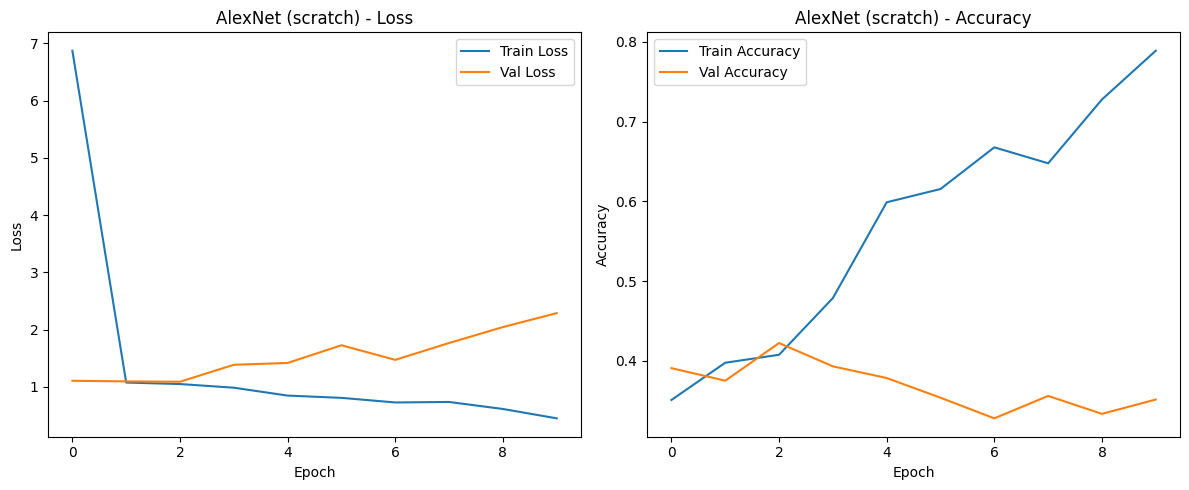

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


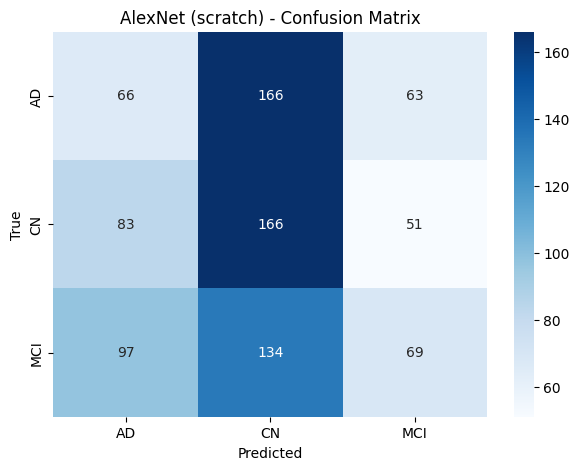

AlexNet (scratch) - Classification Report
              precision    recall  f1-score   support

          AD       0.27      0.22      0.24       295
          CN       0.36      0.55      0.43       300
         MCI       0.38      0.23      0.29       300

    accuracy                           0.34       895
   macro avg       0.33      0.34      0.32       895
weighted avg       0.33      0.34      0.32       895

ROC AUC Score (OvA): 0.5188


In [17]:
plot_history(history_alexnet, "AlexNet (scratch)")
evaluate_predictions(alexnet, X_test_an, y_test_cat, "AlexNet (scratch)")

## 6. Comparison

Pretrained VGG16 vs. from-scratch AlexNet on the same MRI slices.

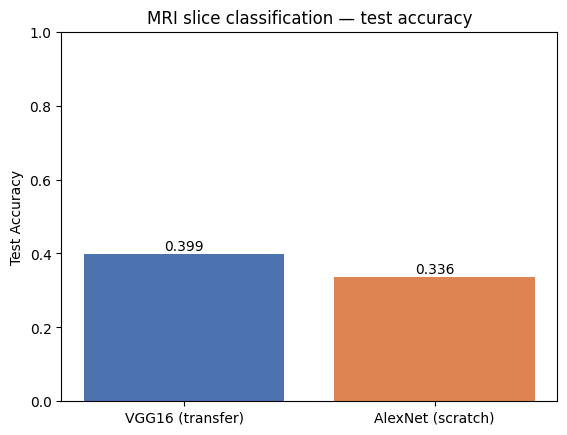

VGG16 (transfer):  0.3989
AlexNet (scratch): 0.3363


In [18]:
vgg_acc = vgg16_tl.evaluate(X_test_vgg, y_test_cat, verbose=0)[1]
alex_acc = alexnet.evaluate(X_test_an, y_test_cat, verbose=0)[1]

plt.bar(['VGG16 (transfer)', 'AlexNet (scratch)'], [vgg_acc, alex_acc],
        color=['#4c72b0', '#dd8452'])
plt.ylabel('Test Accuracy')
plt.title('MRI slice classification — test accuracy')
for i, v in enumerate([vgg_acc, alex_acc]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.ylim(0, 1)
plt.show()

print(f"VGG16 (transfer):  {vgg_acc:.4f}")
print(f"AlexNet (scratch): {alex_acc:.4f}")